<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning-Projects/blob/main/cassava(mobilenetV3S).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Mount Drive & Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Install and Import

In [ ]:
!pip install -q tensorflow pandas scikit-learn matplotlib

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV3Small

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


3. Dataset Paths

In [ ]:
BASE_PATH = "/content/drive/MyDrive/main_dataset/dataset_sir/main_dataset"

TRAIN_CSV = BASE_PATH + "/Train/Train.csv"
TRAIN_DIR = BASE_PATH + "/Train/Train_Images"

TEST_CSV = BASE_PATH + "/Test/Test.csv"
TEST_DIR = BASE_PATH + "/Test/Test_images"

LABEL_JSON = BASE_PATH + "/label_num_to_disease_map.json"

4. Load CSV and JSON

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

with open(LABEL_JSON, "r") as f:
    label_map = json.load(f)

print("Train data:")
print(train_df.head())

print("Test data:")
print(test_df.head())

print("Label map:")
print(label_map)

print("Train columns:", train_df.columns)
print("Test columns:", test_df.columns)


Train data:
               ID  Labels
0  1758913732.jpg       3
1  1241243048.jpg       0
2  3761100385.jpg       2
3  3055614106.jpg       3
4  2386589588.jpg       4
Test data:
               ID  Labels
0  2595356168.jpg       3
1   794817264.jpg       0
2  4270972443.jpg       4
3  3540803278.jpg       0
4  2142522228.jpg       3
Label map:
{'0': 'CBB', '1': 'CBSD', '2': 'CGM', '3': 'CMD', '4': 'Healthy'}
Train columns: Index(['ID', 'Labels'], dtype='object')
Test columns: Index(['ID', 'Labels'], dtype='object')


5. Fix Column Data Types

In [ ]:
train_df["Labels"] = train_df["Labels"].astype(int)
test_df["Labels"] = test_df["Labels"].astype(int)

num_classes = len(label_map)

print("Number of classes:", num_classes)
print("Train class count:")
print(train_df["Labels"].value_counts())

Number of classes: 5
Train class count:
Labels
3    800
0    800
2    800
4    800
1    800
Name: count, dtype: int64


6. Remove Missing Images

In [ ]:
def remove_missing_images(df, image_dir):
    valid_rows = []
    missing_files = []

    for _, row in df.iterrows():
        image_path = os.path.join(image_dir, row["ID"])

        if os.path.exists(image_path):
            valid_rows.append(row)
        else:
            missing_files.append(row["ID"])

    clean_df = pd.DataFrame(valid_rows)

    print("Original rows:", len(df))
    print("Valid rows:", len(clean_df))
    print("Missing files:", len(missing_files))
    print("First missing files:", missing_files[:10])

    return clean_df


print("Cleaning train data...")
train_df = remove_missing_images(train_df, TRAIN_DIR)

print("Cleaning test data...")
test_df = remove_missing_images(test_df, TEST_DIR)

Cleaning train data...
Original rows: 4000
Valid rows: 4000
Missing files: 0
First missing files: []
Cleaning test data...
Original rows: 1000
Valid rows: 1000
Missing files: 0
First missing files: []


7. MobileNetV3 Preprocessing

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def mobilenetv3_preprocess(img):
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0
    return img

8. Create Image Dataset

In [ ]:
def load_image(img_name, label, image_dir):
    image_path = tf.strings.join([image_dir, "/", img_name])

    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = mobilenetv3_preprocess(img)

    return img, label


def make_dataset(df, image_dir, shuffle=True):
    image_names = df["ID"].values
    labels = df["Labels"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_names, labels))

    dataset = dataset.map(
        lambda img_name, label: load_image(img_name, label, image_dir),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, TRAIN_DIR, shuffle=True)
test_ds = make_dataset(test_df, TEST_DIR, shuffle=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


9. Compute Class Weights

In [ ]:
classes = np.unique(train_df["Labels"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["Labels"]
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

Class weights:
{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0), np.int64(3): np.float64(1.0), np.int64(4): np.float64(1.0)}


10. Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

11. Build MobileNetV3Small Model

In [ ]:
base_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=False
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 576)            │         2,304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         2,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,309 (3.60 MB)

 Trainable params: 4,037 (15.77 KB)

 Non-trainable params: 940,272 (3.59 MB)

12. Callbacks

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_cassava_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

13. Train First Stage

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 612s 5s/step - accuracy: 0.3363 - loss: 1.8878 - val_accuracy: 0.4200 - val_loss: 1.4030 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 125s 954ms/step - accuracy: 0.4055 - loss: 1.5776 - val_accuracy: 0.4390 - val_loss: 1.4358 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 125s 967ms/step - accuracy: 0.4370 - loss: 1.4471 - val_accuracy: 0.4510 - val_loss: 1.4112 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 956ms/step - accuracy: 0.4442 - loss: 1.4013 - val_accuracy: 0.4460 - val_loss: 1.4152 - learning_rate: 3.0000e-04
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 123s 943ms/step - accuracy: 0.4593 - loss: 1.3405 - val_accuracy: 0.4530 - val_loss: 1.4267 - learning_rate: 3.0000e-04
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 124s 940ms/step - accuracy: 0.4560 - loss: 1.3512 - val_accuracy: 0.4530 - val_loss: 1.4293 - learning_rate: 9.0000e-05
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 140s 940ms/step

14. Fine-Tune MobileNetV3Small

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.4135 - loss: 1.4600 - val_accuracy: 0.4870 - val_loss: 1.2671 - learning_rate: 1.0000e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.4335 - loss: 1.4207 - val_accuracy: 0.4880 - val_loss: 1.2663 - learning_rate: 1.0000e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.4428 - loss: 1.4012 - val_accuracy: 0.4940 - val_loss: 1.2667 - learning_rate: 1.0000e-05
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.4365 - loss: 1.3990 - val_accuracy: 0.4910 - val_loss: 1.2699 - learning_rate: 1.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.4475 - loss: 1.3833 - val_accuracy: 0.4940 - val_loss: 1.2723 - learning_rate: 3.0000e-06
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.4600 - loss: 1.3661 - val_accuracy: 0.4960 - val_loss: 1.2824 - learning_rate: 3.0000e-06
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - acc

15. Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Final test loss:", loss)
print("Final test accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 526ms/step - accuracy: 0.4960 - loss: 1.2824
Final test loss: 1.2823634147644043
Final test accuracy: 0.4959999918937683


16. Classification Report

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

17. Confusion Matrix

[[145  35   3   6  11]
 [ 58 110   7   7  18]
 [ 34  23  73  46  24]
 [ 17  37  38 104   4]
 [ 70  35  14  17  64]]


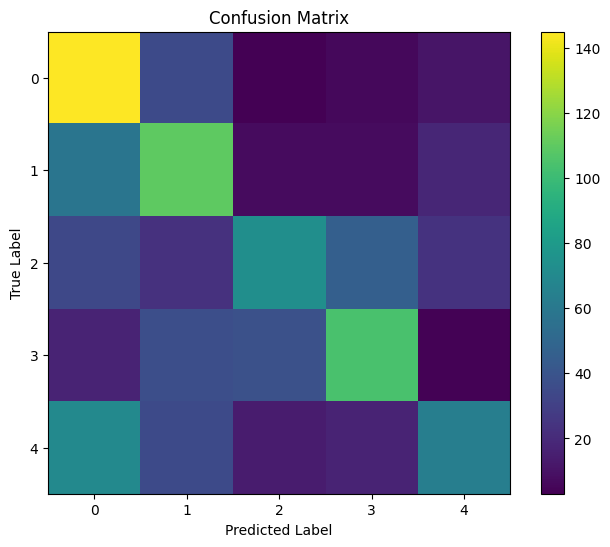

In [ ]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

=>Clean Heatmap using seaborn

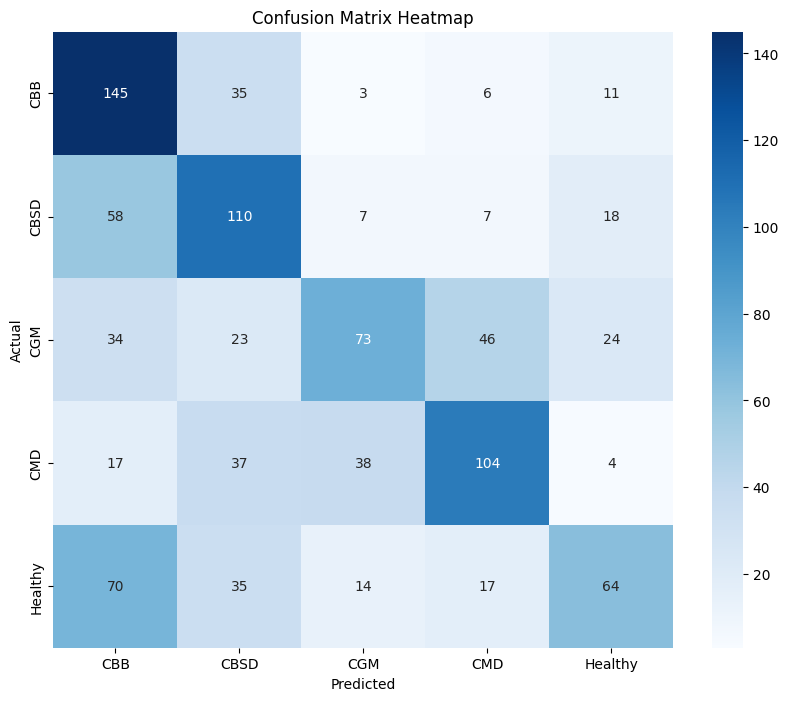

In [ ]:
!pip install seaborn
import seaborn as sns

class_names = [label_map[str(i)] for i in range(len(label_map))]

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()

18. Save Keras Model

In [ ]:
model.save("cassava_mobilenetv3small.keras")
print("Keras model saved.")

Keras model saved.


19. Convert to TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("cassava_mobilenetv3small.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved.")

Saved artifact at '/tmp/tmpo8d87eec'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_174')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136320917473424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917473616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917474576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917474192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917474384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917472464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917475728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917475536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917473232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136320917474768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1363209174

20. Download TFLite Model

In [ ]:
from google.colab import files

files.download("cassava_mobilenetv3small.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

21. Test One Image

In [ ]:
def predict_single_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = mobilenetv3_preprocess(img)

    img = tf.expand_dims(img, axis=0)

    prediction = model.predict(img)

    class_id = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    disease_name = label_map[str(class_id)]

    print("Image:", image_path)
    print("Predicted class ID:", class_id)
    print("Disease:", disease_name)
    print("Confidence:", confidence)


sample_image = os.path.join(TEST_DIR, test_df.iloc[0]["ID"])
predict_single_image(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Image: /content/drive/MyDrive/main_dataset/dataset_sir/main_dataset/Test/Test_images/2595356168.jpg
Predicted class ID: 1
Disease: CBSD
Confidence: 0.3719038665294647
